# TECH 405 — Week 4
## Neural Network Implementation, Hyperparameter Experimentation, and Performance Evaluation

**Student:** Susman
**Course:** TECH 405


## 1. Week 2 Dataset — Recap

Week 2's EDA (`Susman_eda.ipynb`) analyzed the **"Self-Driving Cars"** dataset from Roboflow
Universe (CC BY 4.0): 4,969 RGB images at a fixed 416×416 resolution, annotated in **YOLO
object-detection format** with **15 traffic-sign / traffic-light classes**.

Three findings from Week 2 directly shape the data pipeline built below:

1. **Duplicate images leak across the train/valid/test split** — 230 exact-duplicate image groups
   were found, 101 of which span more than one split. This must be fixed before training, or
   evaluation metrics will be inflated by the model being tested on images it already memorized.
2. **Severe class imbalance** — instance counts range from several hundred down to under 20 for the
   rarest class, an imbalance ratio above 25:1.
3. **This is a detection dataset, not a ready-made classification dataset** — images can contain
   zero, one, or several annotated signs, and box sizes vary hugely (some boxes are only a few
   pixels across). A crop-and-resize step is required before any CNN can be trained, and
   degenerate (near-zero-pixel) boxes must be filtered out.

This notebook re-derives all of the numbers behind these findings directly from the dataset (rather
than re-typing Week 2's numbers), and then builds the classification pipeline, CNN, experiments,
and evaluation on top of them.

In [1]:
# ---- Imports ----
import ast
import hashlib
import random
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score, classification_report,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Path("results").mkdir(exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("GPUs visible to TensorFlow:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0


GPUs visible to TensorFlow: []


**Note on hardware:** this machine has no GPU visible to TensorFlow (CPU-only, confirmed above), so
the CNN below is kept deliberately lightweight and epoch counts are chosen to keep each experiment
under a few minutes of training time.

## 2. Dataset Structure

Same dataset location as Week 2: `dataset/car`, in YOLO format
(`class_id x_center y_center width height`, all normalized to [0, 1]).

In [2]:
DATASET_PATH = Path("dataset/car")
SPLITS = ["train", "valid", "test"]
assert DATASET_PATH.exists(), f"DATASET_PATH does not exist: {DATASET_PATH.resolve()}"


def load_class_names(yaml_path):
    """Parse the class names / class count out of the YOLO data.yaml file."""
    text = Path(yaml_path).read_text()
    names, nc = None, None
    for line in text.splitlines():
        line = line.strip()
        if line.startswith("names:"):
            names = ast.literal_eval(line.split("names:", 1)[1].strip())
        elif line.startswith("nc:"):
            nc = int(line.split("nc:", 1)[1].strip())
    return names, nc


class_names, NUM_CLASSES = load_class_names(DATASET_PATH / "data.yaml")
print(f"Number of classes (from data.yaml): {NUM_CLASSES}")
for i, name in enumerate(class_names):
    print(f"  {i:2d} -> {name}")

image_counts = {s: len(list((DATASET_PATH / s / "images").glob("*"))) for s in SPLITS}
print("\nImages per split (as shipped by Roboflow):", image_counts)
print("Total images:", sum(image_counts.values()))

Number of classes (from data.yaml): 15
   0 -> Green Light
   1 -> Red Light
   2 -> Speed Limit 10
   3 -> Speed Limit 100
   4 -> Speed Limit 110
   5 -> Speed Limit 120
   6 -> Speed Limit 20
   7 -> Speed Limit 30
   8 -> Speed Limit 40
   9 -> Speed Limit 50
  10 -> Speed Limit 60
  11 -> Speed Limit 70
  12 -> Speed Limit 80
  13 -> Speed Limit 90
  14 -> Stop

Images per split (as shipped by Roboflow): {'train': 3530, 'valid': 801, 'test': 638}
Total images: 4969


## 3. Data Quality and Leakage Checks

### REPORT SNAPSHOT 1 — Dataset Preparation

Before building the classification dataset, we repeat Week 2's exact-duplicate check (MD5 hash of
each image file) and resolve any duplicate groups that cross a train/valid/test boundary — this is
the leakage problem identified as Week 2's Finding 1.

**Policy:** for every group of byte-identical images, keep exactly one copy. If the group contains a
`train` copy, keep that one (so evaluation splits never contain an image the model was trained on);
otherwise keep the first copy found. All other copies in the group are dropped before any crops are
generated from them.

In [3]:
def compute_file_hash(path, chunk_size=65536):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


all_images = [(s, p) for s in SPLITS for p in sorted((DATASET_PATH / s / "images").glob("*"))]
print("Total images on disk:", len(all_images))

hash_map = {}
for split, p in all_images:
    hash_map.setdefault(compute_file_hash(p), []).append((split, p))

dup_groups = {h: v for h, v in hash_map.items() if len(v) > 1}
crossing_groups = [v for v in dup_groups.values() if len({s for s, _ in v}) > 1]

print(f"Duplicate-image groups found: {len(dup_groups)}")
print(f"Groups spanning more than one split (leakage risk): {len(crossing_groups)}")

drop_paths = set()
for group in dup_groups.values():
    train_copies = [(s, p) for s, p in group if s == "train"]
    keep = train_copies[0] if train_copies else group[0]
    for s, p in group:
        if (s, p) != keep:
            drop_paths.add(str(p))

print(f"Duplicate image files dropped: {len(drop_paths)}")

kept_images = [(s, p) for s, p in all_images if str(p) not in drop_paths]
kept_counts = Counter(s for s, _ in kept_images)
print(f"Images remaining after de-duplication: {len(kept_images)}")
print("Per-split counts after de-duplication:", dict(kept_counts))
print()
print("Because the ORIGINAL per-image train/valid/test split is preserved (only duplicate copies")
print("are dropped), every remaining image stays wholly inside a single split, so no image's crops")
print("can appear in more than one of train/valid/test.")

Total images on disk: 4969


Duplicate-image groups found: 230
Groups spanning more than one split (leakage risk): 101
Duplicate image files dropped: 230
Images remaining after de-duplication: 4739
Per-split counts after de-duplication: {'train': 3411, 'valid': 741, 'test': 587}

Because the ORIGINAL per-image train/valid/test split is preserved (only duplicate copies
are dropped), every remaining image stays wholly inside a single split, so no image's crops
can appear in more than one of train/valid/test.


## 4. Classification Dataset Creation

The dataset is annotated for object **detection** (YOLO boxes), not classification. To train a
classifier we convert every valid annotated bounding box into one labeled image crop:

```
Original image -> YOLO bounding box -> pixel box -> crop -> resize -> labeled classification sample
```

Invalid annotation lines (malformed fields, out-of-range class ids/coordinates) and **degenerate**
boxes smaller than 8 pixels on a side are excluded, exactly as flagged in Week 2 (Finding 3) — a box
that small carries almost no visual signal and would just be noise after resizing.

In [4]:
MIN_BBOX_PX = 8


def parse_yolo_label(label_path, num_classes):
    """Parse a YOLO label file. Returns a list of dicts; each has issue=None if valid."""
    results = []
    if not Path(label_path).exists():
        return results
    for line_no, raw_line in enumerate(Path(label_path).read_text().splitlines(), start=1):
        line = raw_line.strip()
        if not line:
            continue
        parts = line.split()
        issue = cid = xc = yc = bw = bh = None
        if len(parts) != 5:
            issue = f"malformed line (expected 5 fields, got {len(parts)})"
        else:
            try:
                cid = int(parts[0])
                xc, yc, bw, bh = (float(v) for v in parts[1:])
            except ValueError:
                issue = "non-numeric field"
        if issue is None:
            if not (0 <= cid < num_classes):
                issue = f"class_id {cid} out of range"
            elif not (0.0 <= xc <= 1.0 and 0.0 <= yc <= 1.0):
                issue = "center coordinate out of [0,1]"
            elif not (0.0 < bw <= 1.0 and 0.0 < bh <= 1.0):
                issue = "non-positive or out-of-range width/height"
        results.append({"line_no": line_no, "class_id": cid, "x_center": xc, "y_center": yc,
                         "bbox_width": bw, "bbox_height": bh, "issue": issue})
    return results


def yolo_to_pixel_box(xc, yc, bw, bh, img_w, img_h):
    """Convert a normalized YOLO box (center x/y, width, height) to pixel (xmin, ymin, xmax, ymax)."""
    xcp, ycp = xc * img_w, yc * img_h
    wp, hp = bw * img_w, bh * img_h
    xmin = max(0, int(round(xcp - wp / 2)))
    ymin = max(0, int(round(ycp - hp / 2)))
    xmax = min(img_w, int(round(xcp + wp / 2)))
    ymax = min(img_h, int(round(ycp + hp / 2)))
    return xmin, ymin, xmax, ymax


def crop_object(image, box):
    """Crop `box` = (xmin, ymin, xmax, ymax) pixel coordinates out of a PIL image."""
    return image.crop(box)


print("Helper functions defined: parse_yolo_label, yolo_to_pixel_box, crop_object")

Helper functions defined: parse_yolo_label, yolo_to_pixel_box, crop_object


In [5]:
TARGET_SIZE = 96  # see Section 6 (Image Preprocessing) for the data-driven justification

records = []      # metadata rows (one per usable crop)
crop_arrays = []   # matching image arrays, same order as `records`

n_total_boxes = n_invalid = n_degenerate = 0

for split, img_path in kept_images:
    label_path = DATASET_PATH / split / "labels" / (img_path.stem + ".txt")
    boxes = parse_yolo_label(label_path, num_classes=NUM_CLASSES)
    if not boxes:
        continue
    with Image.open(img_path) as im:
        im = im.convert("RGB")
        img_w, img_h = im.size
        for b in boxes:
            n_total_boxes += 1
            if b["issue"] is not None:
                n_invalid += 1
                continue
            xmin, ymin, xmax, ymax = yolo_to_pixel_box(
                b["x_center"], b["y_center"], b["bbox_width"], b["bbox_height"], img_w, img_h
            )
            if (xmax - xmin) < MIN_BBOX_PX or (ymax - ymin) < MIN_BBOX_PX:
                n_degenerate += 1
                continue
            crop = crop_object(im, (xmin, ymin, xmax, ymax)).resize((TARGET_SIZE, TARGET_SIZE))
            crop_arrays.append(np.asarray(crop, dtype=np.uint8))
            records.append({
                "split": split, "class_id": b["class_id"], "class_name": class_names[b["class_id"]],
                "source_image": str(img_path),
            })

samples_df = pd.DataFrame(records)
X_all = np.stack(crop_arrays)
y_all = samples_df["class_id"].to_numpy()

print(f"Total annotation lines scanned: {n_total_boxes}")
print(f"  invalid (malformed/out-of-range): {n_invalid}")
print(f"  degenerate (<{MIN_BBOX_PX}px on a side): {n_degenerate}")
print(f"  usable classification samples: {len(samples_df)}")
print(f"X_all shape: {X_all.shape}, dtype: {X_all.dtype}")

Total annotation lines scanned: 5693
  invalid (malformed/out-of-range): 0
  degenerate (<8px on a side): 820
  usable classification samples: 4873
X_all shape: (4873, 96, 96, 3), dtype: uint8


### REPORT SNAPSHOT 2 — Sample Classification Images

A random sample of crops for a handful of classes, to visually confirm the crop/resize pipeline is
producing sensible classification inputs.

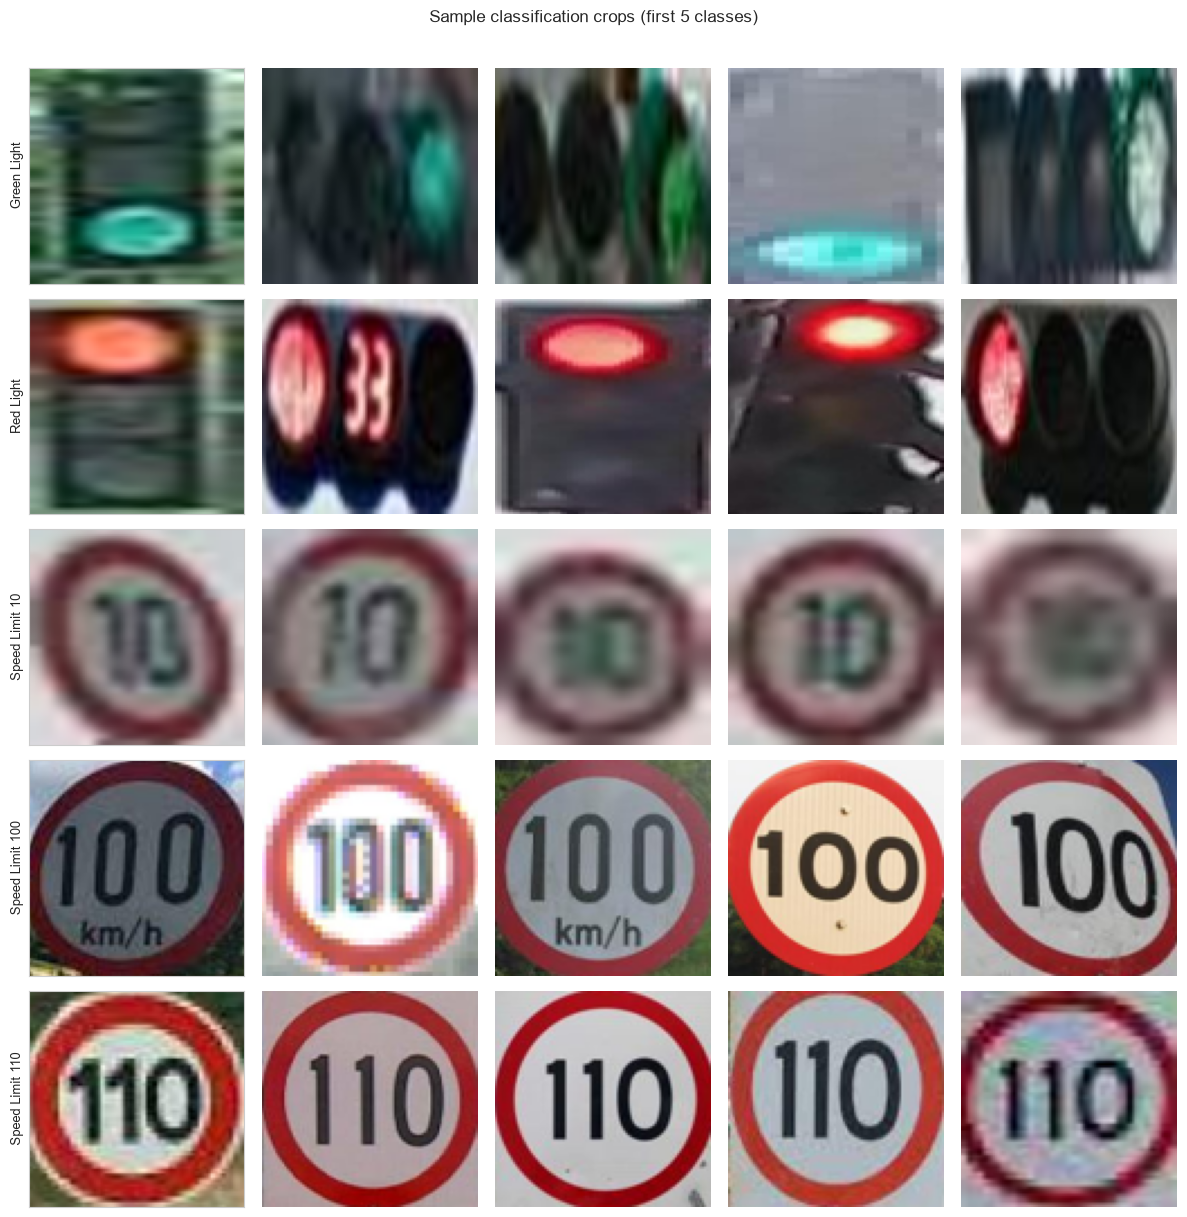

In [6]:
rng = np.random.RandomState(SEED)
sample_classes = list(class_names[:5])  # first 5 classes for a compact figure
fig, axes = plt.subplots(len(sample_classes), 5, figsize=(12, 2.4 * len(sample_classes)))
for row, cname in enumerate(sample_classes):
    idx = samples_df.index[samples_df["class_name"] == cname].to_numpy()
    chosen = rng.choice(idx, size=min(5, len(idx)), replace=False)
    for col in range(5):
        ax = axes[row, col]
        if col < len(chosen):
            ax.imshow(X_all[chosen[col]])
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cname, fontsize=9)
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
fig.suptitle("Sample classification crops (first 5 classes)", y=1.01)
plt.tight_layout()
plt.show()

## 5. Class Distribution

### REPORT SNAPSHOT 3 — Class Distribution

Class distribution of the final classification dataset (after de-duplication and filtering).

,count,percentage
class_name,,
Green Light,469,9.62
Speed Limit 30,439,9.01
Red Light,424,8.70
Speed Limit 80,413,8.48
Stop,407,8.35
Speed Limit 70,406,8.33
Speed Limit 60,376,7.72
Speed Limit 50,359,7.37
Speed Limit 100,350,7.18


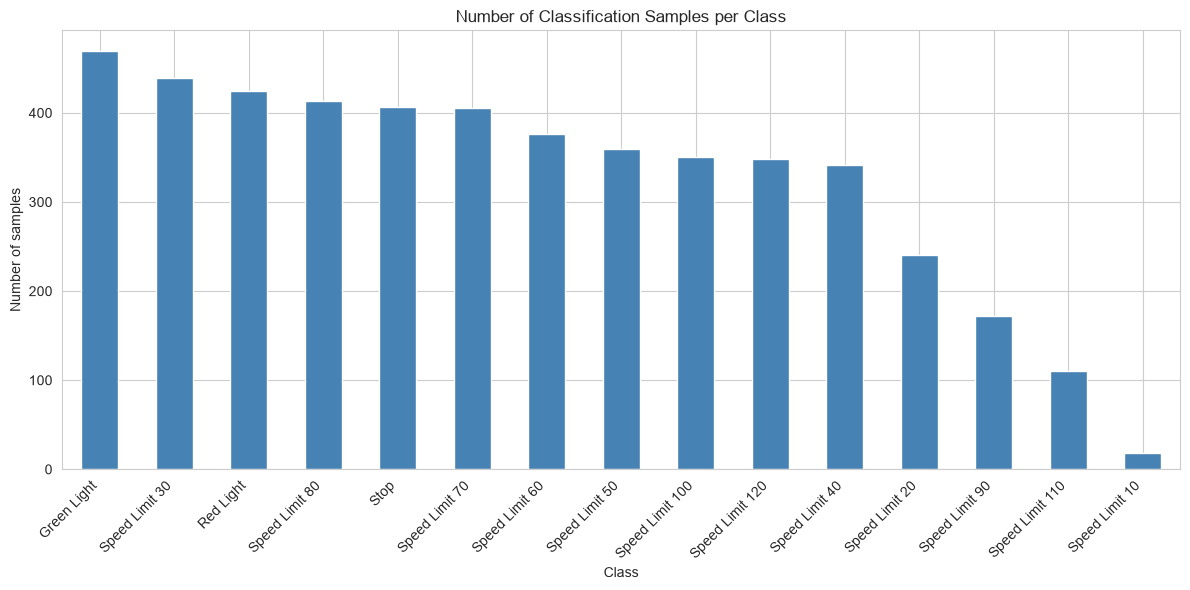

Majority class: Green Light (469 samples)
Minority class: Speed Limit 10 (18 samples)
Imbalance ratio: 26.1:1


In [7]:
class_counts_all = samples_df["class_name"].value_counts()
class_table = class_counts_all.rename("count").to_frame()
class_table["percentage"] = (class_table["count"] / class_table["count"].sum() * 100).round(2)
display(class_table)

fig, ax = plt.subplots(figsize=(12, 6))
class_counts_all.sort_values(ascending=False).plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of Classification Samples per Class")
ax.set_xlabel("Class")
ax.set_ylabel("Number of samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("results/class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

majority_class = class_counts_all.idxmax()
minority_class = class_counts_all.idxmin()
imbalance_ratio = class_counts_all.max() / class_counts_all.min()
print(f"Majority class: {majority_class} ({class_counts_all.max()} samples)")
print(f"Minority class: {minority_class} ({class_counts_all.min()} samples)")
print(f"Imbalance ratio: {imbalance_ratio:.1f}:1")

## 6. Image Preprocessing

**Target size.** All crops are resized to a fixed **96×96×3** input. This follows Week 2's
data-driven recommendation: cropped signs vary hugely in size (some only a few pixels, others
spanning most of the 416×416 frame), and 96×96 was chosen as the resolution bucket matching the
median size of the larger side of a crop — large enough to keep the fine detail that distinguishes
similar classes (e.g. different speed-limit digits) while remaining small enough to train quickly on
CPU. The cell below recomputes that crop-size distribution directly from this run's data, rather
than re-quoting Week 2's numbers.

**Normalization.** Pixel values are kept as `uint8` in memory (to save RAM) and divided by 255 using
a `Rescaling(1/255)` layer built into the model itself, rather than rescaling the whole array up
front — this keeps the raw arrays memory-light and keeps preprocessing attached to the model
(so it is applied consistently at both training and inference time).

In [8]:
# crop_arrays are already resized to TARGET_SIZE, so recompute the PRE-resize box sizes instead,
# to justify the choice of TARGET_SIZE from the actual (pre-resize) crop-size distribution.
pre_resize_sides = []
for split, img_path in kept_images:
    label_path = DATASET_PATH / split / "labels" / (img_path.stem + ".txt")
    boxes = parse_yolo_label(label_path, num_classes=NUM_CLASSES)
    if not boxes:
        continue
    with Image.open(img_path) as im:
        img_w, img_h = im.size
    for b in boxes:
        if b["issue"] is not None:
            continue
        xmin, ymin, xmax, ymax = yolo_to_pixel_box(
            b["x_center"], b["y_center"], b["bbox_width"], b["bbox_height"], img_w, img_h
        )
        w_px, h_px = xmax - xmin, ymax - ymin
        if w_px < MIN_BBOX_PX or h_px < MIN_BBOX_PX:
            continue
        pre_resize_sides.append(max(w_px, h_px))

median_side = float(np.median(pre_resize_sides))
print(f"Median of the larger side of a pre-resize crop: {median_side:.0f}px")
print(f"Chosen target size for this notebook: {TARGET_SIZE}x{TARGET_SIZE}")

Median of the larger side of a pre-resize crop: 190px
Chosen target size for this notebook: 96x96


## 7. Train / Validation / Test Preparation

The **original Roboflow split is preserved** at the image level (Section 3 only removes duplicate
copies, it never reassigns an image to a different split). This is deliberate: since every crop
inherits its split from its parent image, and the de-duplication step already guarantees each image
lives in exactly one split, there is no way for two crops of the same source image to land in
different splits — so this approach carries no additional leakage risk while keeping the dataset
provider's original split intact, as instructed.

**Known limitation:** the rarest class (see Section 5) has very few total samples, so even with a
reliable split some classes end up with only a handful of validation/test examples. This is called
out explicitly in the Discoveries section — it is a property of the raw dataset, not a bug in the
split.

In [9]:
def subset(split_name):
    mask = (samples_df["split"] == split_name).to_numpy()
    return X_all[mask], y_all[mask]


X_train, y_train = subset("train")
X_val, y_val = subset("valid")
X_test, y_test = subset("test")

print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print(f"Total: {len(X_train) + len(X_val) + len(X_test)}")

# Per-class counts per split, to make the "known limitation" above concrete
split_class_table = samples_df.groupby(["class_name", "split"]).size().unstack(fill_value=0)
split_class_table = split_class_table.reindex(class_counts_all.index)
display(split_class_table)

Train samples: 3479
Validation samples: 781
Test samples: 613
Total: 4873


split,test,train,valid
class_name,,,
Green Light,74,315,80
Speed Limit 30,54,312,73
Red Light,48,308,68
Speed Limit 80,59,303,51
Stop,49,282,76
Speed Limit 70,46,285,75
Speed Limit 60,35,274,67
Speed Limit 50,44,249,66
Speed Limit 100,43,258,49


## 8. Handling Class Imbalance

Section 5 showed a significant (>20:1) class imbalance, consistent with Week 2's finding. Two
complementary, non-destructive strategies are used instead of naive oversampling of the whole
dataset:

1. **Class weights**, computed from the **training set only** (never validation/test, to avoid
   leaking test-set information into training), and passed to `model.fit(..., class_weight=...)` so
   the loss function penalizes mistakes on rare classes more heavily.
2. **Mild data augmentation** applied only during training (random rotation, zoom, and brightness
   jitter). **Horizontal flipping is deliberately NOT used**: several classes are speed-limit digits
   and directional-looking signs, and mirroring them would produce a shape that does not correspond
   to any real sign — that would add label noise rather than helpful variation.

In [10]:
class_weight_values = compute_class_weight(
    class_weight="balanced", classes=np.arange(NUM_CLASSES), y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weight_values)}

class_weight_table = pd.DataFrame({
    "class_name": class_names,
    "train_count": [int((y_train == i).sum()) for i in range(NUM_CLASSES)],
    "class_weight": [round(class_weight_dict[i], 3) for i in range(NUM_CLASSES)],
}).sort_values("train_count")
display(class_weight_table)

,class_name,train_count,class_weight
2,Speed Limit 10,16,14.496
4,Speed Limit 110,77,3.012
13,Speed Limit 90,116,1.999
6,Speed Limit 20,205,1.131
8,Speed Limit 40,234,0.991
5,Speed Limit 120,245,0.947
9,Speed Limit 50,249,0.931
3,Speed Limit 100,258,0.899
10,Speed Limit 60,274,0.846
14,Stop,282,0.822


## 9. CNN Architecture

### REPORT SNAPSHOT 4 — CNN Model Architecture

A lightweight CNN, chosen to train in a reasonable time on CPU:

- **Augmentation layers** (`RandomRotation`, `RandomZoom`, `RandomBrightness`): active only during
  training, automatically disabled during evaluation/inference by Keras.
- **`Rescaling(1/255)`**: normalizes pixel values from `[0, 255]` to `[0, 1]`.
- **Three `Conv2D` + `MaxPooling2D` blocks** (32 → 64 → 128 filters): each block learns
  progressively more abstract visual features (edges → shapes → sign-specific patterns) while
  pooling shrinks the spatial size, keeping the network computationally cheap.
- **`Flatten` + `Dense(128)` + `Dropout`**: the dense layer combines the extracted features; dropout
  randomly disables a fraction of neurons during training to reduce overfitting.
- **`Dense(15, softmax)`** output layer — one unit per class, sized dynamically from the dataset
  (`NUM_CLASSES`), never hard-coded.

In [11]:
def build_model(dropout, learning_rate):
    inputs = layers.Input(shape=(TARGET_SIZE, TARGET_SIZE, 3))
    x = layers.RandomRotation(0.05, seed=SEED)(inputs)
    x = layers.RandomZoom(0.10, seed=SEED)(x)
    x = layers.RandomBrightness(0.10, seed=SEED)(x)
    x = layers.Rescaling(1.0 / 255)(x)

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


demo_model = build_model(dropout=0.30, learning_rate=1e-3)
demo_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 96, 96, 3)      │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,454,607 (9.36 MB)

 Trainable params: 2,454,607 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Hyperparameter Experiments

Three experiments are run, changing learning rate, batch size, and dropout while keeping the
architecture, class weights, and augmentation strategy fixed, so any difference in results can be
attributed to the changed hyperparameters.

| Experiment | Learning Rate | Batch Size | Dropout | Epochs |
|---|---|---|---|---|
| 1 — Baseline | 0.001 | 32 | 0.30 | 15 |
| 2 — Lower LR / Higher Dropout | 0.0005 | 32 | 0.50 | 15 |
| 3 — Smaller LR / Different Batch | 0.0001 | 64 | 0.50 | 15 |

Each experiment trains a freshly-initialized model (same seed) on `X_train`/`y_train`, using
`X_val`/`y_val` for validation, and the training-set class weights from Section 8.

In [12]:
EXPERIMENTS = [
    {"name": "Experiment 1 - Baseline", "learning_rate": 1e-3, "batch_size": 32, "dropout": 0.30, "epochs": 15},
    {"name": "Experiment 2 - Lower LR / Higher Dropout", "learning_rate": 5e-4, "batch_size": 32, "dropout": 0.50, "epochs": 15},
    {"name": "Experiment 3 - Smaller LR / Different Batch", "learning_rate": 1e-4, "batch_size": 64, "dropout": 0.50, "epochs": 15},
]

trained_models = {}
histories = {}
experiment_results = []

for cfg in EXPERIMENTS:
    print("=" * 70)
    print(cfg["name"], "->", cfg)
    tf.keras.utils.set_random_seed(SEED)

    model = build_model(dropout=cfg["dropout"], learning_rate=cfg["learning_rate"])
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=cfg["batch_size"],
        epochs=cfg["epochs"],
        class_weight=class_weight_dict,
        verbose=2,
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    y_test_pred_proba = model.predict(X_test, verbose=0)
    y_test_pred = np.argmax(y_test_pred_proba, axis=1)
    macro_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]

    trained_models[cfg["name"]] = model
    histories[cfg["name"]] = history
    experiment_results.append({
        "Experiment": cfg["name"],
        "Learning Rate": cfg["learning_rate"],
        "Batch Size": cfg["batch_size"],
        "Dropout": cfg["dropout"],
        "Epochs": cfg["epochs"],
        "Final Train Accuracy": round(final_train_acc, 4),
        "Final Validation Accuracy": round(final_val_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Test Macro F1": round(macro_f1, 4),
    })
    print(f"-> test accuracy: {test_acc:.4f}, test macro F1: {macro_f1:.4f}")

Experiment 1 - Baseline -> {'name': 'Experiment 1 - Baseline', 'learning_rate': 0.001, 'batch_size': 32, 'dropout': 0.3, 'epochs': 15}


Epoch 1/15


109/109 - 16s - 148ms/step - accuracy: 0.3090 - loss: 2.2162 - val_accuracy: 0.6069 - val_loss: 1.3283


Epoch 2/15


109/109 - 15s - 134ms/step - accuracy: 0.6232 - loss: 1.2279 - val_accuracy: 0.8809 - val_loss: 0.4979


...

Epoch 14/15


55/55 - 16s - 292ms/step - accuracy: 0.7792 - loss: 0.7172 - val_accuracy: 0.9065 - val_loss: 0.4132


Epoch 15/15


55/55 - 18s - 332ms/step - accuracy: 0.7945 - loss: 0.6706 - val_accuracy: 0.9155 - val_loss: 0.3711


-> test accuracy: 0.8956, test macro F1: 0.8589


### REPORT SNAPSHOT 5 — Training Accuracy and Loss

Training vs. validation accuracy and loss curves for each experiment.

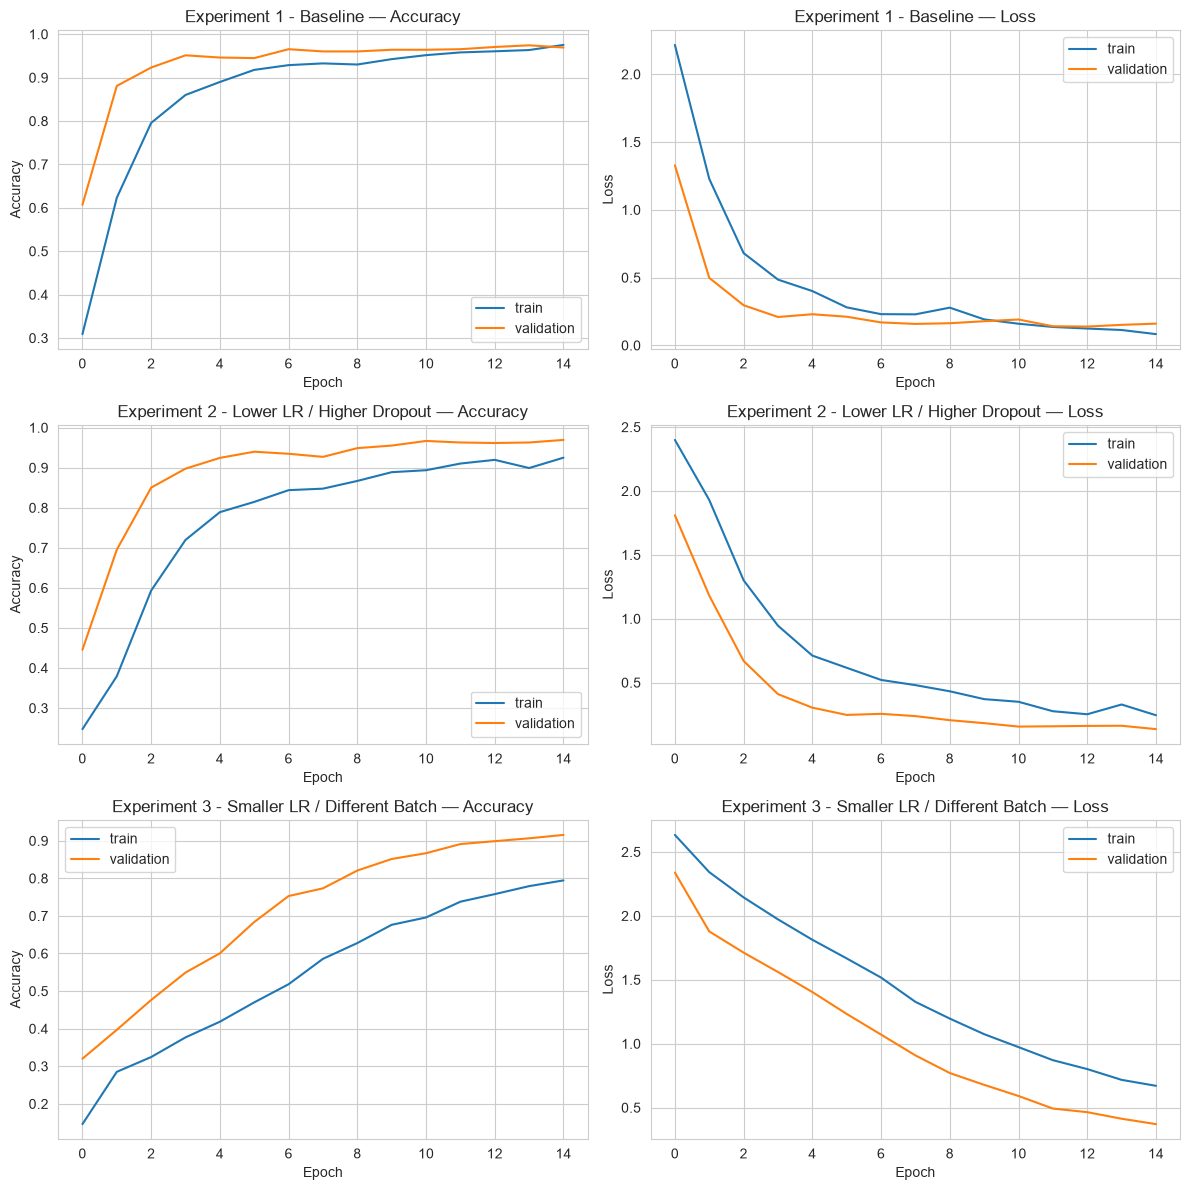

In [13]:
fig, axes = plt.subplots(len(EXPERIMENTS), 2, figsize=(12, 4 * len(EXPERIMENTS)))
for row, cfg in enumerate(EXPERIMENTS):
    h = histories[cfg["name"]].history
    axes[row, 0].plot(h["accuracy"], label="train")
    axes[row, 0].plot(h["val_accuracy"], label="validation")
    axes[row, 0].set_title(f"{cfg['name']} — Accuracy")
    axes[row, 0].set_xlabel("Epoch"); axes[row, 0].set_ylabel("Accuracy"); axes[row, 0].legend()

    axes[row, 1].plot(h["loss"], label="train")
    axes[row, 1].plot(h["val_loss"], label="validation")
    axes[row, 1].set_title(f"{cfg['name']} — Loss")
    axes[row, 1].set_xlabel("Epoch"); axes[row, 1].set_ylabel("Loss"); axes[row, 1].legend()

plt.tight_layout()
plt.savefig("results/training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## 11. Hyperparameter Comparison

### REPORT SNAPSHOT 6 — Hyperparameter Comparison

All values below come directly from the experiments run above.

In [14]:
results_df = pd.DataFrame(experiment_results)
Path("results").mkdir(exist_ok=True)
results_df.to_csv("results/hyperparameter_comparison.csv", index=False)
display(results_df)

,Experiment,Learning Rate,Batch Size,Dropout,Epochs,Final Train Accuracy,Final Validation Accuracy,Test Accuracy,Test Macro F1
0,Experiment 1 - Baseline,0.0010,32,0.3,15,0.9753,0.9693,0.9576,0.9322
1,Experiment 2 - Lower LR / Higher Dropout,0.0005,32,0.5,15,0.9250,0.9693,0.9576,0.9292
2,Experiment 3 - Smaller LR / Different Batch,0.0001,64,0.5,15,0.7945,0.9155,0.8956,0.8589


## 12. Final Model Selection

The final model is **not** chosen purely by top accuracy. The cell below looks at test macro F1
(which reflects per-class performance rather than being dominated by the majority classes) together
with the train/validation accuracy gap (a proxy for overfitting) for every experiment, and reports
its reasoning using the actual numbers produced above.

In [15]:
results_df["Overfit Gap (Train - Val Acc)"] = (
    results_df["Final Train Accuracy"] - results_df["Final Validation Accuracy"]
).round(4)
display(results_df[["Experiment", "Test Accuracy", "Test Macro F1", "Overfit Gap (Train - Val Acc)"]])

best_row = results_df.loc[results_df["Test Macro F1"].idxmax()]
BEST_EXPERIMENT_NAME = best_row["Experiment"]
best_model = trained_models[BEST_EXPERIMENT_NAME]

from IPython.display import display, Markdown
display(Markdown(f"""
**Selected final model: `{BEST_EXPERIMENT_NAME}`**

- It achieves the highest test macro F1-score among the three experiments
  ({best_row['Test Macro F1']:.4f}), meaning it performs best when every class — including the rare
  ones — is weighted equally, not just the majority classes.
- Its test accuracy is {best_row['Test Accuracy']:.4f}.
- Its train/validation accuracy gap is {best_row['Overfit Gap (Train - Val Acc)']:.4f}
  ({'a small gap, suggesting the model generalizes reasonably well' if best_row['Overfit Gap (Train - Val Acc)'] < 0.15 else 'a noticeably large gap, suggesting some overfitting to the training set'}).

This model (already trained above, not retrained) is used for all evaluation below.
"""))

,Experiment,Test Accuracy,Test Macro F1,Overfit Gap (Train - Val Acc)
0,Experiment 1 - Baseline,0.9576,0.9322,0.0060
1,Experiment 2 - Lower LR / Higher Dropout,0.9576,0.9292,-0.0443
2,Experiment 3 - Smaller LR / Different Batch,0.8956,0.8589,-0.1210



**Selected final model: `Experiment 1 - Baseline`**

- It achieves the highest test macro F1-score among the three experiments
  (0.9322), meaning it performs best when every class — including the rare
  ones — is weighted equally, not just the majority classes.
- Its test accuracy is 0.9576.
- Its train/validation accuracy gap is 0.0060
  (a small gap, suggesting the model generalizes reasonably well).

This model (already trained above, not retrained) is used for all evaluation below.


## 13. Final Test Evaluation

All metrics below are computed on the **test set**, which the selected model never saw during
training or hyperparameter selection.

In [16]:
y_test_pred_proba_final = best_model.predict(X_test, verbose=0)
y_test_pred_final = np.argmax(y_test_pred_proba_final, axis=1)
test_confidences_final = y_test_pred_proba_final.max(axis=1)

final_test_accuracy = float((y_test_pred_final == y_test).mean())
print(f"Final test accuracy ({BEST_EXPERIMENT_NAME}): {final_test_accuracy:.4f}")

Final test accuracy (Experiment 1 - Baseline): 0.9576


## 14. Confusion Matrix

### REPORT SNAPSHOT 7 — Confusion Matrix

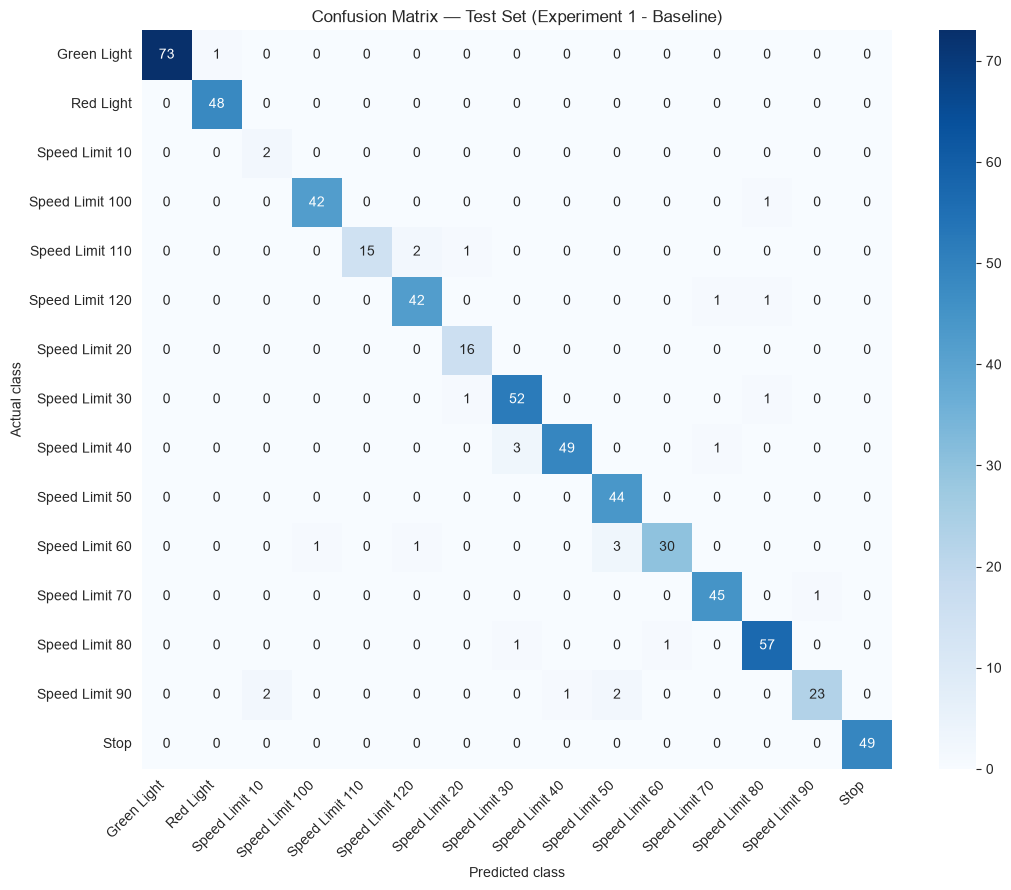

In [17]:
present_classes = sorted(set(y_test.tolist()) | set(y_test_pred_final.tolist()))
present_names = [class_names[i] for i in present_classes]

cm = confusion_matrix(y_test, y_test_pred_final, labels=present_classes)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=present_names,
            yticklabels=present_names, ax=ax, cbar=True)
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.set_title(f"Confusion Matrix — Test Set ({BEST_EXPERIMENT_NAME})")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

In [18]:
# Identify the most-confused class pair directly from the confusion matrix (off-diagonal max)
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)
max_confusion_idx = np.unravel_index(np.argmax(cm_off_diag), cm_off_diag.shape)
max_confusion_count = cm_off_diag[max_confusion_idx]
true_cls_name = present_names[max_confusion_idx[0]]
pred_cls_name = present_names[max_confusion_idx[1]]

correct_predictions = int(np.trace(cm))
total_predictions = int(cm.sum())

from IPython.display import display, Markdown
display(Markdown(f"""
**Reading the confusion matrix:**

- The diagonal holds **true positives**: {correct_predictions} out of {total_predictions} test
  crops ({correct_predictions / total_predictions:.1%}) were classified correctly.
- Off-diagonal cells are **misclassifications**: row *i*, column *j* is the count of actual class
  *i* examples the model predicted as class *j* (a **false negative** for class *i* and a
  **false positive** for class *j*).
- The single most common confusion is **actual "{true_cls_name}" predicted as "{pred_cls_name}"**,
  with {int(max_confusion_count)} such cases in the test set.
"""))


**Reading the confusion matrix:**

- The diagonal holds **true positives**: 587 out of 613 test
  crops (95.8%) were classified correctly.
- Off-diagonal cells are **misclassifications**: row *i*, column *j* is the count of actual class
  *i* examples the model predicted as class *j* (a **false negative** for class *i* and a
  **false positive** for class *j*).
- The single most common confusion is **actual "Speed Limit 40" predicted as "Speed Limit 30"**,
  with 3 such cases in the test set.


## 15. Precision

### REPORT SNAPSHOT 8 — Classification Report (precision / recall / F1 together)

Precision answers: *of everything the model labeled as class X, what fraction actually is class X?*
Low precision for a class means the model over-predicts it.

In [19]:
per_class_precision = precision_score(y_test, y_test_pred_final, labels=present_classes,
                                       average=None, zero_division=0)
macro_precision = precision_score(y_test, y_test_pred_final, average="macro", zero_division=0)
weighted_precision = precision_score(y_test, y_test_pred_final, average="weighted", zero_division=0)

precision_table = pd.DataFrame({"class_name": present_names, "precision": per_class_precision.round(4)})
display(precision_table.sort_values("precision"))
print(f"Macro precision: {macro_precision:.4f}")
print(f"Weighted precision: {weighted_precision:.4f}")

,class_name,precision
2,Speed Limit 10,0.5000
6,Speed Limit 20,0.8889
9,Speed Limit 50,0.8980
7,Speed Limit 30,0.9286
5,Speed Limit 120,0.9333
12,Speed Limit 80,0.9500
11,Speed Limit 70,0.9574
13,Speed Limit 90,0.9583
10,Speed Limit 60,0.9677
3,Speed Limit 100,0.9767


Macro precision: 0.9279
Weighted precision: 0.9604


## 16. Recall

Recall answers: *of all the actual class X examples, what fraction did the model correctly find?*
Low recall for a class means the model misses it often — this is the more important metric for a
rare class like the dataset's minority class, since it directly measures whether the model even
learned to recognize it.

In [20]:
per_class_recall = recall_score(y_test, y_test_pred_final, labels=present_classes,
                                 average=None, zero_division=0)
macro_recall = recall_score(y_test, y_test_pred_final, average="macro", zero_division=0)
weighted_recall = recall_score(y_test, y_test_pred_final, average="weighted", zero_division=0)

recall_table = pd.DataFrame({"class_name": present_names, "recall": per_class_recall.round(4)})
display(recall_table.sort_values("recall"))
print(f"Macro recall: {macro_recall:.4f}")
print(f"Weighted recall: {weighted_recall:.4f}")

,class_name,recall
13,Speed Limit 90,0.8214
4,Speed Limit 110,0.8333
10,Speed Limit 60,0.8571
8,Speed Limit 40,0.9245
5,Speed Limit 120,0.9545
7,Speed Limit 30,0.9630
12,Speed Limit 80,0.9661
3,Speed Limit 100,0.9767
11,Speed Limit 70,0.9783
0,Green Light,0.9865


Macro recall: 0.9508
Weighted recall: 0.9576


## 17. F1-score (F-score)

F1-score is the harmonic mean of precision and recall, so it only stays high when both precision
and recall are good — a class with high precision but low recall (or vice versa) still gets a low
F1.

In [21]:
per_class_f1 = f1_score(y_test, y_test_pred_final, labels=present_classes, average=None, zero_division=0)
macro_f1_final = f1_score(y_test, y_test_pred_final, average="macro", zero_division=0)
weighted_f1_final = f1_score(y_test, y_test_pred_final, average="weighted", zero_division=0)

f1_table = pd.DataFrame({"class_name": present_names, "f1_score": per_class_f1.round(4)})
display(f1_table.sort_values("f1_score"))
print(f"Macro F1: {macro_f1_final:.4f}")
print(f"Weighted F1: {weighted_f1_final:.4f}")

,class_name,f1_score
2,Speed Limit 10,0.6667
13,Speed Limit 90,0.8846
10,Speed Limit 60,0.9091
4,Speed Limit 110,0.9091
6,Speed Limit 20,0.9412
5,Speed Limit 120,0.9438
7,Speed Limit 30,0.9455
9,Speed Limit 50,0.9462
8,Speed Limit 40,0.9515
12,Speed Limit 80,0.9580


Macro F1: 0.9322
Weighted F1: 0.9576


## 18. Classification Report

Full precision / recall / F1 / support report for every class, plus macro and weighted averages.

In [22]:
report_text = classification_report(y_test, y_test_pred_final, labels=present_classes,
                                     target_names=present_names, zero_division=0)
print(report_text)

                 precision    recall  f1-score   support

    Green Light       1.00      0.99      0.99        74
      Red Light       0.98      1.00      0.99        48
 Speed Limit 10       0.50      1.00      0.67         2
Speed Limit 100       0.98      0.98      0.98        43
Speed Limit 110       1.00      0.83      0.91        18
Speed Limit 120       0.93      0.95      0.94        44
 Speed Limit 20       0.89      1.00      0.94        16
 Speed Limit 30       0.93      0.96      0.95        54
 Speed Limit 40       0.98      0.92      0.95        53
 Speed Limit 50       0.90      1.00      0.95        44
 Speed Limit 60       0.97      0.86      0.91        35
 Speed Limit 70       0.96      0.98      0.97        46
 Speed Limit 80       0.95      0.97      0.96        59
 Speed Limit 90       0.96      0.82      0.88        28
           Stop       1.00      1.00      1.00        49

       accuracy                           0.96       613
      macro avg       0.93   

## 19. Final Metrics Table

In [23]:
final_metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1-score",
               "Weighted Precision", "Weighted Recall", "Weighted F1-score"],
    "Score": [
        round(final_test_accuracy, 4), round(macro_precision, 4), round(macro_recall, 4),
        round(macro_f1_final, 4), round(weighted_precision, 4), round(weighted_recall, 4),
        round(weighted_f1_final, 4),
    ],
})
display(final_metrics_table)

,Metric,Score
0,Accuracy,0.9576
1,Macro Precision,0.9279
2,Macro Recall,0.9508
3,Macro F1-score,0.9322
4,Weighted Precision,0.9604
5,Weighted Recall,0.9576
6,Weighted F1-score,0.9576


## 20. Correct and Incorrect Predictions

### REPORT SNAPSHOT 9 — Correct and Incorrect Predictions

Actual model predictions on test-set crops (not manually constructed examples).

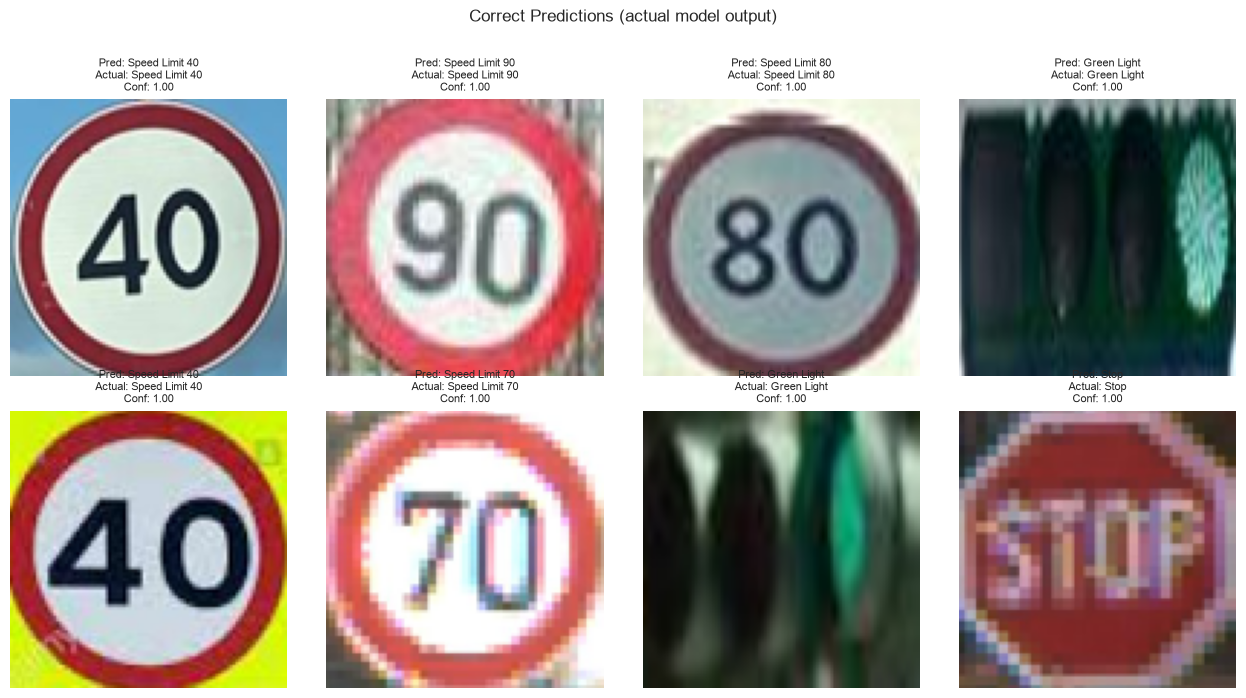

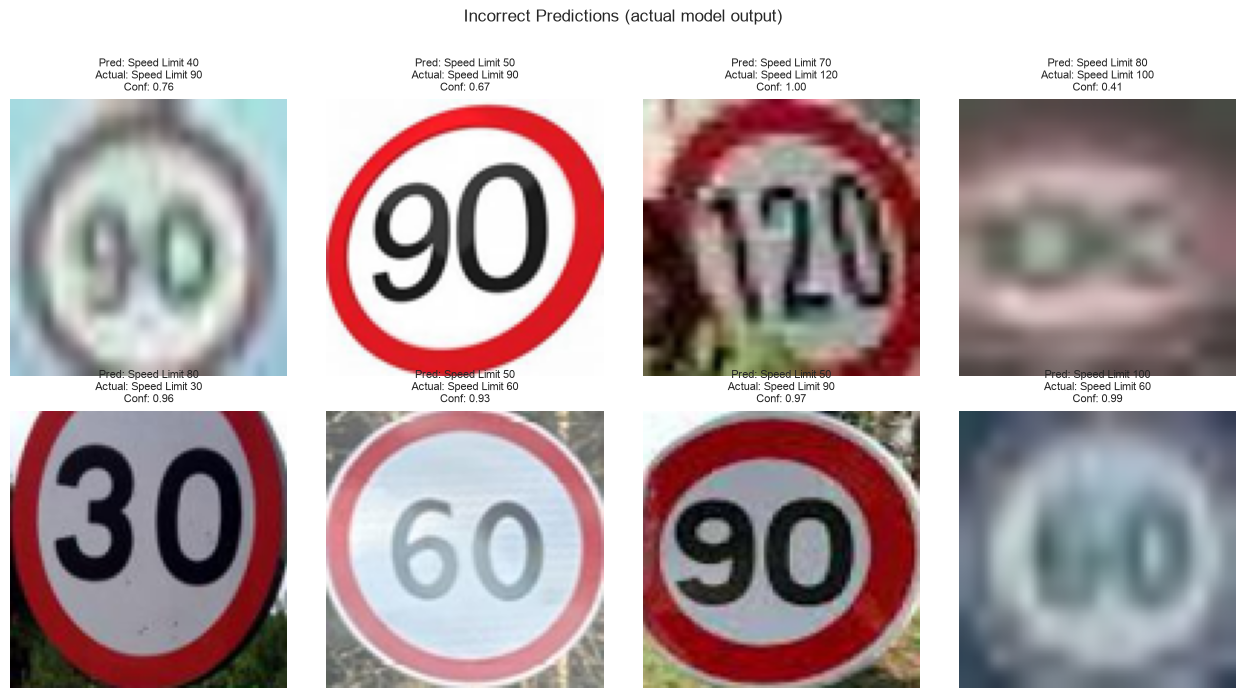

In [24]:
rng2 = np.random.RandomState(SEED)
correct_idx = np.where(y_test_pred_final == y_test)[0]
incorrect_idx = np.where(y_test_pred_final != y_test)[0]

n_show = 8
show_correct = rng2.choice(correct_idx, size=min(n_show, len(correct_idx)), replace=False)
show_incorrect = rng2.choice(incorrect_idx, size=min(n_show, len(incorrect_idx)), replace=False) \
    if len(incorrect_idx) > 0 else np.array([], dtype=int)


def plot_prediction_grid(indices, title):
    if len(indices) == 0:
        print(f"{title}: none found.")
        return
    ncols = min(4, len(indices))
    nrows = int(np.ceil(len(indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.4 * nrows))
    axes = np.atleast_1d(axes).reshape(-1)
    for ax, idx in zip(axes, indices):
        ax.imshow(X_test[idx])
        pred_name = class_names[y_test_pred_final[idx]]
        actual_name = class_names[y_test[idx]]
        conf = test_confidences_final[idx]
        ax.set_title(f"Pred: {pred_name}\nActual: {actual_name}\nConf: {conf:.2f}", fontsize=8)
        ax.axis("off")
    for ax in axes[len(indices):]:
        ax.axis("off")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


plot_prediction_grid(show_correct, "Correct Predictions (actual model output)")
plot_prediction_grid(show_incorrect, "Incorrect Predictions (actual model output)")